# IEEE-CIS Fraud Detection — Deep Neural Network

This notebook trains a **Deep Neural Network (DNN)** on the preprocessed IEEE-CIS fraud detection data.  
It picks up directly from `Preprocessing.ipynb`, loading the saved CSV splits and metadata.

---

## Architecture Overview

### Embedding Block (Categorical Features)
Each label-encoded categorical column gets its own **`nn.Embedding`** layer, which learns a dense low-dimensional representation during training.  
- Embedding dimension: `min(50, (vocab_size + 1) // 2)` — a standard heuristic that prevents oversized embeddings for high-cardinality features like `card1`.
- All embeddings are concatenated with the scaled numerical features to form the full input vector.

### MLP Backbone
```
Input  (num_numerical + sum_of_embedding_dims)
  │
  ├─ BatchNorm → Linear(512) → GELU → Dropout(0.3)
  ├─ BatchNorm → Linear(256) → GELU → Dropout(0.3)
  ├─ BatchNorm → Linear(128) → GELU → Dropout(0.2)
  ├─ BatchNorm → Linear(64)  → GELU → Dropout(0.2)
  │
  └─ Linear(1) → Sigmoid → fraud probability
```

### Design Rationale
| Choice | Why |
|---|---|
| **Embeddings** for categoricals | Learns richer representations than one-hot; handles high-cardinality (e.g. `card1` with 13k+ values) without memory explosion |
| **BatchNorm** before each layer | Stabilises training with large input variance; allows higher learning rates |
| **GELU** activation | Smoother gradient flow than ReLU; works well on tabular data |
| **Dropout** (0.3 → 0.2) | Regularises; higher dropout in wider layers where overfitting risk is greater |
| **Shrinking layer widths** (512→256→128→64) | Progressively compresses representation — wider early layers capture interactions, narrower later layers extract the decision boundary |
| **Adam optimiser** | Adaptive per-parameter learning rates handle the large feature heterogeneity in this dataset |
| **SGD warmup → Adam** | Cold-start SGD for the first few epochs prevents Adam from making large gradient steps before embeddings have stabilised |
| **BCEWithLogitsLoss + pos_weight** | Addresses severe class imbalance (~3.5% fraud). `pos_weight = (n_neg / n_pos)` penalises false negatives more |
| **Cosine Annealing LR scheduler** | Smoothly decays learning rate; combined with Adam it often finds flatter minima |

### Metrics
Fraud detection is an **imbalanced classification** problem.  
- **AUC-ROC** — primary metric; measures discrimination power regardless of threshold
- **AUC-PR** (Average Precision) — more informative than ROC on imbalanced data; measures precision-recall trade-off
- **F1 Score** — harmonic mean of precision and recall at the 0.5 threshold
- **Precision / Recall** — at default threshold
- **Confusion Matrix** — shows TP/FP/TN/FN counts

## 1. Imports

In [1]:
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    precision_recall_curve,
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print('\nLibraries loaded successfully!')

Using device: cuda
  GPU: NVIDIA GeForce MX550
  VRAM: 2.1 GB

Libraries loaded successfully!


## 2. Load Preprocessed Data & Metadata

In [2]:
DATA_DIR = 'preprocessed'

train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
val_df   = pd.read_csv(f'{DATA_DIR}/val.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test.csv')

with open(f'{DATA_DIR}/column_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

cat_cols   = metadata['cat_cols']        # label-encoded categoricals
num_cols   = metadata['num_cols']        # scaled numericals
vocab_sizes = metadata['vocab_sizes']    # {col: vocab_size} for embedding layers
target     = metadata['target']          # 'isFraud'

# Only keep cat_cols that exist in the dataframe (safety guard)
cat_cols  = [c for c in cat_cols  if c in train_df.columns]
num_cols  = [c for c in num_cols  if c in train_df.columns]

print(f'Train      : {train_df.shape}')
print(f'Validation : {val_df.shape}')
print(f'Test       : {test_df.shape}')
print(f'\nNumerical features  : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'\nFraud rate — Train: {train_df[target].mean():.3%} | Val: {val_df[target].mean():.3%} | Test: {test_df[target].mean():.3%}')

Train      : (472443, 272)
Validation : (29516, 272)
Test       : (88581, 272)

Numerical features  : 252
Categorical features: 19

Fraud rate — Train: 3.499% | Val: 3.500% | Test: 3.498%


## 3. PyTorch Dataset

In [3]:
class FraudDataset(Dataset):
    """
    Returns:
        num_feats  : FloatTensor of scaled numerical features
        cat_feats  : LongTensor of label-encoded categorical indices (for Embedding)
        label      : FloatTensor scalar (0 or 1)
    """
    def __init__(self, df, num_cols, cat_cols, target):
        self.num_data = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.cat_data = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.labels   = torch.tensor(df[target].values,  dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.num_data[idx], self.cat_data[idx], self.labels[idx]


# ── Datasets & DataLoaders ────────────────────────────────────────────────────
BATCH_SIZE = 4096   # Large batch: takes advantage of GPU throughput
NUM_WORKERS = 0     # Parallel data loading; set to 0 if you hit issues on Windows

train_ds = FraudDataset(train_df, num_cols, cat_cols, target)
val_ds   = FraudDataset(val_df,   num_cols, cat_cols, target)
test_ds  = FraudDataset(test_df,  num_cols, cat_cols, target)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 116
Val batches   : 8
Test batches  : 22


## 4. Model Architecture

In [4]:
class FraudDNN(nn.Module):
    """
    Deep Neural Network for fraud detection.

    Architecture:
    ┌──────────────────────────────────┐
    │  Embedding layers (per cat col)  │  ← learns dense representations
    └──────────────┬───────────────────┘
                   │ concatenate with numerical features
                   ▼
    ┌──────────────────────────────────┐
    │  BatchNorm → Linear(512) → GELU  │
    │  Dropout(0.3)                    │
    ├──────────────────────────────────┤
    │  BatchNorm → Linear(256) → GELU  │
    │  Dropout(0.3)                    │
    ├──────────────────────────────────┤
    │  BatchNorm → Linear(128) → GELU  │
    │  Dropout(0.2)                    │
    ├──────────────────────────────────┤
    │  BatchNorm → Linear(64)  → GELU  │
    │  Dropout(0.2)                    │
    ├──────────────────────────────────┤
    │  Linear(1)  → raw logit          │  ← BCEWithLogitsLoss handles sigmoid
    └──────────────────────────────────┘
    """

    def __init__(self, num_numerical: int, vocab_sizes: dict,
                 hidden_dims=(512, 256, 128, 64),
                 dropout_rates=(0.3, 0.3, 0.2, 0.2)):
        super().__init__()

        # ── Embedding layers ─────────────────────────────────────────────────
        # Embedding dim heuristic: min(50, (vocab+1)//2)
        # Prevents oversized embeddings for high-cardinality features
        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=min(50, (vocab_size + 1) // 2)
            )
            for col, vocab_size in vocab_sizes.items()
            if col in cat_cols  # only embed columns that exist in data
        })

        total_embed_dim = sum(
            min(50, (v + 1) // 2)
            for col, v in vocab_sizes.items()
            if col in cat_cols
        )

        input_dim = num_numerical + total_embed_dim

        # ── MLP backbone ─────────────────────────────────────────────────────
        layers = []
        in_dim = input_dim
        for out_dim, drop in zip(hidden_dims, dropout_rates):
            layers.extend([
                nn.BatchNorm1d(in_dim),
                nn.Linear(in_dim, out_dim),
                nn.GELU(),
                nn.Dropout(drop)
            ])
            in_dim = out_dim

        layers.append(nn.Linear(in_dim, 1))  # output logit
        self.mlp = nn.Sequential(*layers)

        # Weight initialisation — He init for linear layers
        self._init_weights()

    def _init_weights(self):
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, num_feats, cat_feats):
        # cat_feats: (batch, num_cat_cols) — each col's index goes to its embedding
        embed_out = []
        for i, col in enumerate(cat_cols):
            if col in self.embeddings:
                embed_out.append(self.embeddings[col](cat_feats[:, i]))

        if embed_out:
            x = torch.cat([num_feats] + embed_out, dim=1)
        else:
            x = num_feats

        return self.mlp(x).squeeze(1)  # (batch,) logits


# ── Instantiate ──────────────────────────────────────────────────────────────
model = FraudDNN(
    num_numerical=len(num_cols),
    vocab_sizes=vocab_sizes
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'\nModel architecture:')
print(model)

Total parameters    : 1,179,237
Trainable parameters: 1,179,237

Model architecture:
FraudDNN(
  (embeddings): ModuleDict(
    (ProductCD): Embedding(6, 3)
    (card1): Embedding(12819, 50)
    (card2): Embedding(502, 50)
    (card3): Embedding(115, 50)
    (card4): Embedding(6, 3)
    (card5): Embedding(116, 50)
    (card6): Embedding(6, 3)
    (addr1): Embedding(307, 50)
    (addr2): Embedding(71, 36)
    (P_emaildomain): Embedding(61, 31)
    (M1): Embedding(4, 2)
    (M2): Embedding(4, 2)
    (M3): Embedding(4, 2)
    (M4): Embedding(5, 3)
    (M5): Embedding(4, 2)
    (M6): Embedding(4, 2)
    (M7): Embedding(4, 2)
    (M8): Embedding(4, 2)
    (M9): Embedding(4, 2)
  )
  (mlp): Sequential(
    (0): BatchNorm1d(597, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Linear(in_features=597, out_features=512, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_

## 5. Loss, Optimiser & Scheduler

In [5]:
# ── Class imbalance weight ────────────────────────────────────────────────────
# pos_weight = (number of negatives) / (number of positives)
# This tells BCEWithLogitsLoss to penalise missed frauds more
n_pos = train_df[target].sum()
n_neg = len(train_df) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f'Positives (fraud)  : {int(n_pos):,}')
print(f'Negatives (legit)  : {int(n_neg):,}')
print(f'pos_weight applied : {pos_weight.item():.2f}x')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ── Optimiser ─────────────────────────────────────────────────────────────────
# Adam with mild weight decay for L2 regularisation
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8
)

# ── Learning rate scheduler ───────────────────────────────────────────────────
# CosineAnnealingLR: smoothly decays LR from lr → eta_min over T_max epochs
# This helps the model settle into flatter minima in later epochs
NUM_EPOCHS = 30
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print(f'\nOptimiser : Adam (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})')
print(f'Scheduler : CosineAnnealingLR (T_max={NUM_EPOCHS}, eta_min=1e-6)')
print(f'Epochs    : {NUM_EPOCHS}')

Positives (fraud)  : 16,531
Negatives (legit)  : 455,912
pos_weight applied : 27.58x

Optimiser : Adam (lr=0.001, wd=0.0001)
Scheduler : CosineAnnealingLR (T_max=30, eta_min=1e-6)
Epochs    : 30


## 6. Output Directory

In [6]:
# ── Output directory (mirrors base_code convention) ──────────────────────────
import datetime, json as _json

RUN_NAME = "DNN (GELU, 4-Layer, Embeddings)"  # change as needed
TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join("model_outputs", f"{TIMESTAMP}_{RUN_NAME.replace(' ', '_')}")
os.makedirs(RUN_DIR, exist_ok=True)
print(f"Run name : {RUN_NAME}")
print(f"Output   : {RUN_DIR}")

Run name : DNN (GELU, 4-Layer, Embeddings)
Output   : model_outputs\20260405_225841_DNN_(GELU,_4-Layer,_Embeddings)


## 7. Helper Functions

In [7]:
# ── Helper functions (standardised from base_code) ───────────────────────────

def train_epoch(model, loader, optimizer, criterion):
    """Run one training epoch; returns average loss."""
    model.train()
    total_loss = 0
    for num_feats, cat_feats, y in loader:
        num_feats = num_feats.to(device)
        cat_feats = cat_feats.to(device)
        y         = y.to(device)
        optimizer.zero_grad()
        logits = model(num_feats, cat_feats)
        loss   = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_metrics(model, loader):
    """Returns PR-AUC (Average Precision) on the given loader."""
    model.eval()
    all_proba, all_y = [], []
    for num_feats, cat_feats, y in loader:
        num_feats = num_feats.to(device)
        cat_feats = cat_feats.to(device)
        logits    = model(num_feats, cat_feats)
        proba     = torch.sigmoid(logits).cpu().numpy()
        all_proba.extend(proba)
        all_y.extend(y.numpy())
    return average_precision_score(np.array(all_y), np.array(all_proba))


@torch.no_grad()
def get_predictions(model, loader):
    """Returns (y_true, y_proba) arrays for the given loader."""
    model.eval()
    all_proba, all_y = [], []
    for num_feats, cat_feats, y in loader:
        num_feats = num_feats.to(device)
        cat_feats = cat_feats.to(device)
        logits    = model(num_feats, cat_feats)
        proba     = torch.sigmoid(logits).cpu().numpy()
        all_proba.extend(proba)
        all_y.extend(y.numpy())
    return np.array(all_y), np.array(all_proba)


def plot_confusion_matrix(y_true, y_proba, threshold=0.5, title="Test Set", save_dir='.'):
    y_pred = (y_proba >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
                yticklabels=['True Non-Fraud', 'True Fraud'])
    axes[0].set_title(f'{title} — Confusion Matrix (threshold={threshold:.3f})\nCounts')

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
                yticklabels=['True Non-Fraud', 'True Fraud'])
    axes[1].set_title(f'{title} — Confusion Matrix (threshold={threshold:.3f})\nRow-normalised')

    plt.tight_layout()
    cm_path = os.path.join(save_dir, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=150)
    plt.show()

    print(f"\nClassification Report (threshold={threshold:.3f}):")
    report = classification_report(y_true, y_pred, target_names=['Non-Fraud', 'Fraud'])
    print(report)
    with open(os.path.join(save_dir, 'classification_report.txt'), 'w') as f:
        f.write(f"Threshold: {threshold:.3f}\n\n")
        f.write(report)
    print(f"Confusion matrix saved to {cm_path}")

## 8. Training

In [8]:
N_EPOCHS_FULL = NUM_EPOCHS   # set in Section 5

print(f"\n{'='*60}")
print(f"Full training for {N_EPOCHS_FULL} epochs")
print(f"{'='*60}\n")

history         = {'train_loss': [], 'val_pr': []}
best_state      = None
best_val_pr_auc = 0

print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

epoch_log_rows = []
for epoch in range(1, N_EPOCHS_FULL + 1):
    t0         = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_pr     = evaluate_metrics(model, val_loader)
    scheduler.step()
    elapsed    = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_pr'].append(val_pr)

    if val_pr > best_val_pr_auc:
        best_val_pr_auc = val_pr
        best_state      = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"  {epoch:>6}/{N_EPOCHS_FULL}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")
    epoch_log_rows.append({'epoch': epoch, 'train_loss': train_loss,
                           'val_pr': val_pr, 'time_s': round(elapsed, 1)})

pd.DataFrame(epoch_log_rows).to_csv(os.path.join(RUN_DIR, 'training_log.csv'), index=False)


Full training for 30 epochs

   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/30    1.0371      0.4358   116.1s
       2/30    0.8373      0.4907    40.4s
       3/30    0.7499      0.5387    36.6s
       4/30    0.6828      0.5711    36.7s
       5/30    0.6283      0.6104    36.8s
       6/30    0.5756      0.6376    36.0s
       7/30    0.5362      0.6502    35.6s
       8/30    0.5055      0.6601    35.8s
       9/30    0.4748      0.6769    35.1s
      10/30    0.4464      0.6847    35.9s
      11/30    0.4211      0.7036    35.8s
      12/30    0.4026      0.7037    36.5s
      13/30    0.3727      0.7163    36.6s
      14/30    0.3619      0.7216    34.0s
      15/30    0.3463      0.7259    34.8s
      16/30    0.3268      0.7280    36.4s
      17/30    0.3140      0.7358    34.9s
      18/30    0.2999      0.7441    35.0s
      19/30    0.2894      0.7467    36.6s
      20/30    0.2795      0.7491    35.4s
      21/30    0.2644      0.7

## 9. Evaluation

In [9]:
model.load_state_dict(best_state)
val_pr  = evaluate_metrics(model, val_loader)
test_pr = evaluate_metrics(model, test_loader)

print(f"\n{'='*50}")
print(f"  Checkpoint PR-AUC (recall deferred to PR curve)")
print(f"{'='*50}")
print(f"  Val  PR-AUC : {val_pr:.4f}")
print(f"  Test PR-AUC : {test_pr:.4f}")


  Checkpoint PR-AUC (recall deferred to PR curve)
  Val  PR-AUC : 0.7629
  Test PR-AUC : 0.7542


## 10. Plots

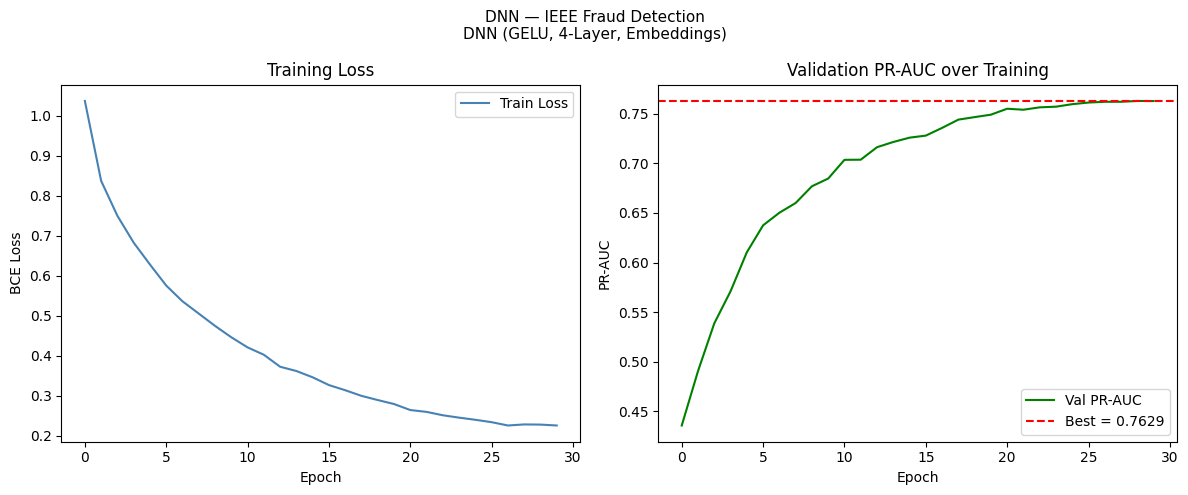

Training curves saved to model_outputs\20260405_225841_DNN_(GELU,_4-Layer,_Embeddings)\dnn_training_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(history['train_loss'], label='Train Loss', color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Training Loss')
ax.legend()

ax = axes[1]
ax.plot(history['val_pr'], label='Val PR-AUC', color='green')
ax.axhline(y=best_val_pr_auc, color='red', linestyle='--', label=f'Best = {best_val_pr_auc:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('PR-AUC')
ax.set_title('Validation PR-AUC over Training')
ax.legend()

plt.suptitle(f'DNN — IEEE Fraud Detection\n{RUN_NAME}', fontsize=11)
plt.tight_layout()
curves_path = os.path.join(RUN_DIR, 'dnn_training_curves.png')
plt.savefig(curves_path, dpi=150)
plt.show()
print(f"Training curves saved to {curves_path}")

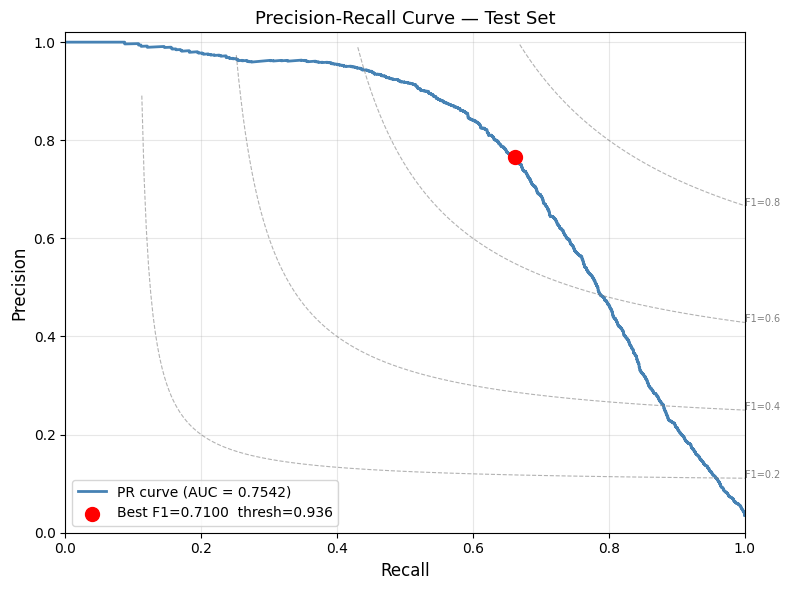

PR curve saved to model_outputs\20260405_225841_DNN_(GELU,_4-Layer,_Embeddings)\pr_curve.png


In [11]:
## PR Curve + best threshold based on F1

y_true, y_proba = get_predictions(model, test_loader)

precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_proba)

# F1 at every threshold (precision/recall have one extra trailing point — align)
f1_scores   = (2 * precision_pts[:-1] * recall_pts[:-1]
               / (precision_pts[:-1] + recall_pts[:-1] + 1e-8))
best_idx    = np.argmax(f1_scores)
best_thresh = float(thresholds[best_idx])
best_f1     = float(f1_scores[best_idx])

# Recall and precision at the best-F1 threshold
best_recall    = float(recall_pts[best_idx])
best_precision = float(precision_pts[best_idx])

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(recall_pts, precision_pts, color='steelblue', lw=2,
        label=f'PR curve (AUC = {test_pr:.4f})')
ax.scatter(best_recall, best_precision, color='red', zorder=5, s=100,
           label=f'Best F1={best_f1:.4f}  thresh={best_thresh:.3f}')

for f1_iso in [0.2, 0.4, 0.6, 0.8]:
    r_vals = np.linspace(0.01, 1.0, 300)
    p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
    mask   = (p_vals >= 0) & (p_vals <= 1)
    ax.plot(r_vals[mask], p_vals[mask], '--', color='grey', lw=0.8, alpha=0.6)
    ax.annotate(f'F1={f1_iso}', xy=(r_vals[mask][-1], p_vals[mask][-1]),
                fontsize=7, color='grey')

ax.set_xlabel('Recall',    fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Test Set', fontsize=13)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
pr_curve_path = os.path.join(RUN_DIR, 'pr_curve.png')
plt.savefig(pr_curve_path, dpi=150)
plt.show()
print(f"PR curve saved to {pr_curve_path}")

In [12]:
val_y_true, val_proba = get_predictions(model, val_loader)
val_recall  = recall_score(val_y_true,
                           (val_proba  >= best_thresh).astype(int),
                           zero_division=0)
test_recall = best_recall   # already computed above from PR curve

print(f"\n{'='*50}")
print(f"  Final Results at best threshold = {best_thresh:.3f}")
print(f"{'='*50}")
print(f"  Test PR-AUC  : {test_pr:.4f}")
print(f"  Test F1      : {best_f1:.4f}")
print(f"  Test Recall  : {test_recall:.4f}")
print(f"  Test Precision: {best_precision:.4f}")
print(f"  Val  Recall  : {val_recall:.4f}")

# Save final metrics
final_metrics = {
    'run_name'       : RUN_NAME,
    'val_pr_auc'     : val_pr,
    'test_pr_auc'    : test_pr,
    'best_thresh'    : best_thresh,
    'test_f1'        : best_f1,
    'test_recall'    : test_recall,
    'test_precision' : best_precision,
    'val_recall'     : val_recall,
}
import json as _json
metrics_path = os.path.join(RUN_DIR, 'final_metrics.json')
with open(metrics_path, 'w') as f:
    _json.dump(final_metrics, f, indent=2)
print(f"\nFinal metrics saved to {metrics_path}")


  Final Results at best threshold = 0.936
  Test PR-AUC  : 0.7542
  Test F1      : 0.7100
  Test Recall  : 0.6612
  Test Precision: 0.7666
  Val  Recall  : 0.6670

Final metrics saved to model_outputs\20260405_225841_DNN_(GELU,_4-Layer,_Embeddings)\final_metrics.json


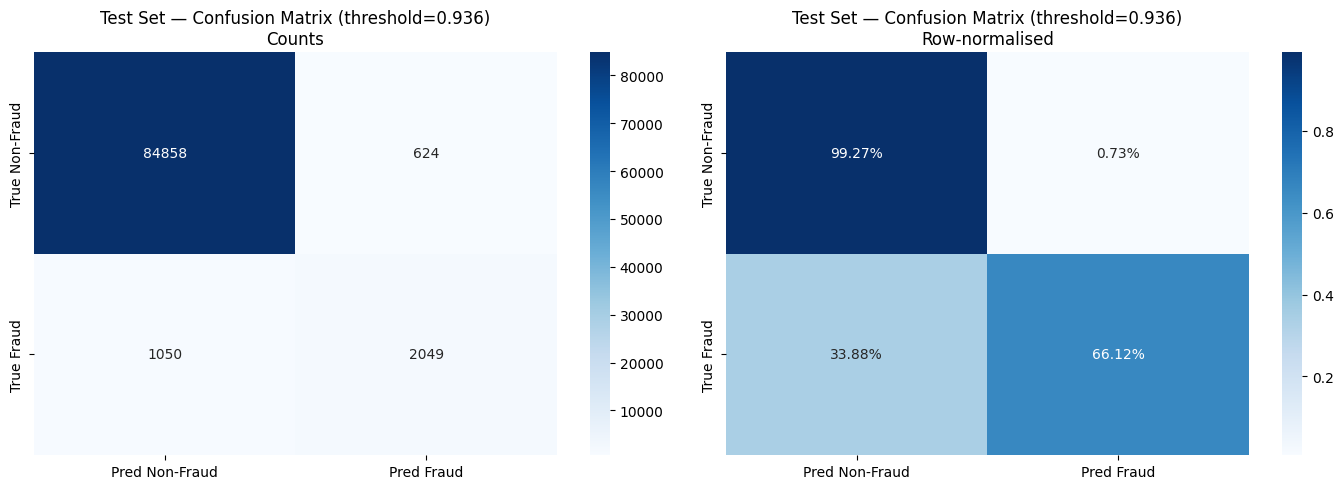


Classification Report (threshold=0.936):
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99     85482
       Fraud       0.77      0.66      0.71      3099

    accuracy                           0.98     88581
   macro avg       0.88      0.83      0.85     88581
weighted avg       0.98      0.98      0.98     88581

Confusion matrix saved to model_outputs\20260405_225841_DNN_(GELU,_4-Layer,_Embeddings)\confusion_matrix.png


In [13]:
plot_confusion_matrix(y_true, y_proba, threshold=best_thresh, save_dir=RUN_DIR)

## 11. Save Model

In [ ]:
model_path = os.path.join(RUN_DIR, 'dnn_model.pt')
torch.save({
    'model_state_dict' : best_state,
    'run_name'         : RUN_NAME,
    'val_pr_auc'       : val_pr,
    'test_pr_auc'      : test_pr,
    'best_thresh'      : best_thresh,
    'test_recall'      : test_recall,
    'val_recall'       : val_recall,
    'cat_cols'         : cat_cols,
    'num_cols'         : num_cols,
    'vocab_sizes'      : vocab_sizes,
}, model_path)
print(f"Model saved to {model_path}")

print(f"\n{'='*50}")
print(f"  All outputs saved to: {RUN_DIR}/")
print(f"    dnn_training_curves.png")
print(f"    pr_curve.png")
print(f"    confusion_matrix.png")
print(f"    classification_report.txt")
print(f"    training_log.csv")
print(f"    final_metrics.json")
print(f"    dnn_model.pt")
print(f"{'='*50}")